U24AI063

SUNIL JAAT

                            Lab-Assignment-03

# Experiment 3: Dimensionality Reduction Using Principal Component Analysis (PCA)

**Mapped CO(s):** CO2, CO4

**Aim:** To perform dimensionality reduction using Principal Component Analysis (PCA) on the Titanic dataset using Python.

## Objectives
- To understand the concept of dimensionality reduction.
- To preprocess data before applying PCA.
- To standardize numerical features.
- To apply PCA using Scikit-learn.
- To visualize the principal components.
- To analyze the explained variance of each principal component.

## Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# For nicer plots
sns.set_style("whitegrid")
%matplotlib inline

## Step 2: Load the Titanic Dataset

We use Seaborn's built-in Titanic dataset (equivalent to the Kaggle version).

In [2]:
titanic = sns.load_dataset('titanic')
print("Shape of dataset:", titanic.shape)
titanic.head()

Shape of dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 3: Select Numerical Features

As per the experiment, we use the following numerical attributes:

| Attribute | Description |
|---|---|
| age | Age of passenger |
| fare | Ticket fare |
| sibsp | Number of siblings/spouses aboard |
| parch | Number of parents/children aboard |
| pclass | Passenger class |

In [3]:
features = ['age', 'fare', 'sibsp', 'parch', 'pclass']
data = titanic[features].copy()
print("Selected numerical features:")
data.head()

Selected numerical features:


,age,fare,sibsp,parch,pclass
0,22.0,7.2500,1,0,3
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,3
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,3


## Step 4: Handle Missing Values

In [4]:
print("Missing values before handling:")
print(data.isnull().sum())

# Fill missing 'age' values with the median age
data['age'] = data['age'].fillna(data['age'].median())

# Drop any remaining rows with missing values (if any)
data = data.dropna()

print("\nMissing values after handling:")
print(data.isnull().sum())
print("\nShape after handling missing values:", data.shape)

Missing values before handling:
age       177
fare        0
sibsp       0
parch       0
pclass      0
dtype: int64

Missing values after handling:
age       0
fare      0
sibsp     0
parch     0
pclass    0
dtype: int64

Shape after handling missing values: (891, 5)


## Step 5: Standardize the Data

PCA is sensitive to the scale of features, so we standardize the data using `StandardScaler`.

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df.head()

,age,fare,sibsp,parch,pclass
0,-0.565736,-0.502445,0.432793,-0.473674,0.827377
1,0.663861,0.786845,0.432793,-0.473674,-1.566107
2,-0.258337,-0.488854,-0.474545,-0.473674,0.827377
3,0.433312,0.420730,0.432793,-0.473674,-1.566107
4,0.433312,-0.486337,-0.474545,-0.473674,0.827377


## Step 6: Apply PCA (2 Principal Components)

In [6]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,1.140660,-0.076520
1,-1.768445,0.133479
2,0.879196,-0.726606
3,-1.458103,0.071555
4,0.561252,-0.943713


## Step 7: Explained Variance

In [7]:
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio for each component:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

print(f"\nTotal variance explained by 2 components: {sum(explained_variance)*100:.2f}%")

Explained variance ratio for each component:
PC1: 0.3396 (33.96%)
PC2: 0.3252 (32.52%)

Total variance explained by 2 components: 66.48%


## Step 8: Visualize the First Two Principal Components

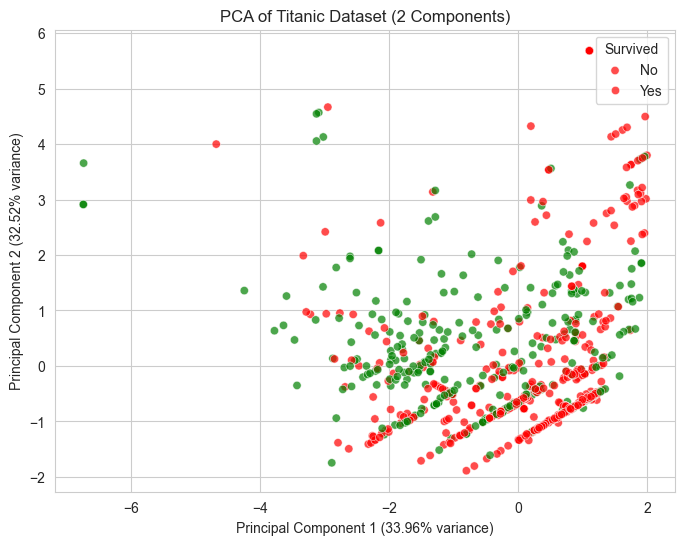

In [8]:
plt.figure(figsize=(8, 6))
survived = titanic.loc[data.index, 'survived']
sns.scatterplot(x='PC1', y='PC2', hue=survived, palette=['red', 'green'], data=pca_df, alpha=0.7)
plt.title('PCA of Titanic Dataset (2 Components)')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}% variance)')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## Step 9: Interpret the Results

- Numerical features (`age`, `fare`, `sibsp`, `parch`, `pclass`) were standardized so each contributes equally.
- PCA reduced the 5-dimensional feature space into 2 principal components.
- The explained variance ratio shows how much information (variance) each component retains from the original data.
- The scatter plot allows us to visually inspect patterns/clusters in the reduced 2D space.

## Experimental Results

**Observation**
- Numerical features were successfully selected.
- Missing values were removed before PCA.
- Data was standardized using StandardScaler.
- PCA reduced the dataset to two principal components.
- Most of the information was retained after dimensionality reduction.
- The scatter plot clearly visualized the transformed data.

**Result**

Principal Component Analysis was successfully applied to the Titanic dataset, reducing the dimensionality while preserving most of the important information.

**Conclusion**

The experiment demonstrated how Principal Component Analysis (PCA) can effectively reduce the dimensionality of a dataset while retaining maximum variance. PCA simplifies data visualization, reduces computational complexity, and improves the efficiency of machine learning algorithms.

---
## Exercises / Assignments

### 1. Apply PCA using three principal components

In [9]:
pca_3 = PCA(n_components=3)
pc_3 = pca_3.fit_transform(scaled_data)

pca_3_df = pd.DataFrame(data=pc_3, columns=['PC1', 'PC2', 'PC3'])
print("Explained variance ratio (3 components):")
for i, var in enumerate(pca_3.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")
print(f"\nTotal variance explained: {sum(pca_3.explained_variance_ratio_)*100:.2f}%")
pca_3_df.head()

Explained variance ratio (3 components):
PC1: 0.3396 (33.96%)
PC2: 0.3252 (32.52%)
PC3: 0.1446 (14.46%)

Total variance explained: 80.94%


,PC1,PC2,PC3
0,1.140660,-0.076520,-0.190298
1,-1.768445,0.133479,-0.104458
2,0.879196,-0.726606,-0.180297
3,-1.458103,0.071555,-0.160840
4,0.561252,-0.943713,0.371067


### 2. Plot the explained variance ratio of each component

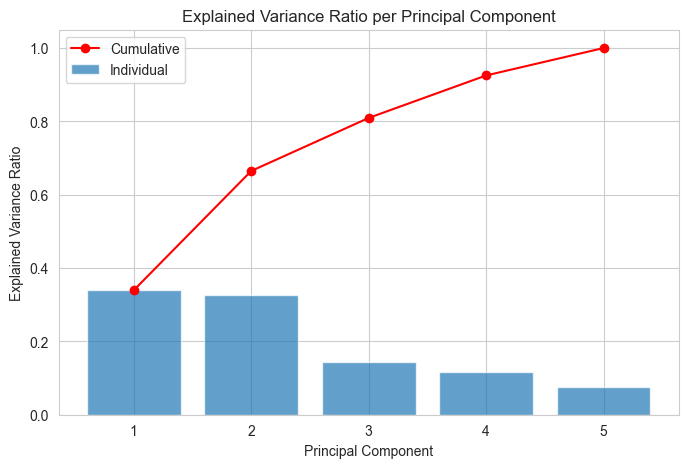

In [10]:
pca_full = PCA(n_components=len(features))
pca_full.fit(scaled_data)

plt.figure(figsize=(8, 5))
components = range(1, len(features) + 1)
plt.bar(components, pca_full.explained_variance_ratio_, alpha=0.7, label='Individual')
plt.plot(components, np.cumsum(pca_full.explained_variance_ratio_), marker='o', color='red', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per Principal Component')
plt.xticks(components)
plt.legend()
plt.show()

### 3. Compare the dataset before and after PCA

In [11]:
print("Original dataset shape:", data.shape)
print("PCA-reduced dataset shape (2 components):", pca_df.shape)

print("\nOriginal (standardized) features sample:")
display(scaled_df.head(3))

print("\nPCA-transformed (2 components) sample:")
display(pca_df.head(3))

print(f"\nOriginal number of features: {data.shape[1]}")
print(f"Reduced number of features: {pca_df.shape[1]}")
print(f"Variance retained with 2 components: {sum(explained_variance)*100:.2f}%")

Original dataset shape: (891, 5)
PCA-reduced dataset shape (2 components): (891, 2)

Original (standardized) features sample:


,age,fare,sibsp,parch,pclass
0,-0.565736,-0.502445,0.432793,-0.473674,0.827377
1,0.663861,0.786845,0.432793,-0.473674,-1.566107
2,-0.258337,-0.488854,-0.474545,-0.473674,0.827377



PCA-transformed (2 components) sample:


,PC1,PC2
0,1.140660,-0.076520
1,-1.768445,0.133479
2,0.879196,-0.726606



Original number of features: 5
Reduced number of features: 2
Variance retained with 2 components: 66.48%


### 4. Interpret the first two principal components

We can inspect the PCA "loadings" (component weights) to see how much each original feature contributes to PC1 and PC2.

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)
print("PCA Loadings (feature contribution to each component):")
loadings

PCA Loadings (feature contribution to each component):


,PC1,PC2
age,-0.457655,-0.315236
fare,-0.559469,0.367648
sibsp,0.124736,0.615183
parch,0.031850,0.619955
pclass,0.678950,-0.051643


**Interpretation:**
- The feature with the largest absolute value in PC1 contributes most to the direction of maximum variance.
- The feature with the largest absolute value in PC2 contributes most to the second (orthogonal) direction of variance.
- Features with similar signs and magnitudes in a component tend to be positively correlated in that direction; opposite signs indicate an inverse relationship along that component.

### 5. Apply PCA to another dataset (Iris dataset example)

Explained variance ratio (Iris dataset):
PC1: 0.7296 (72.96%)
PC2: 0.2285 (22.85%)


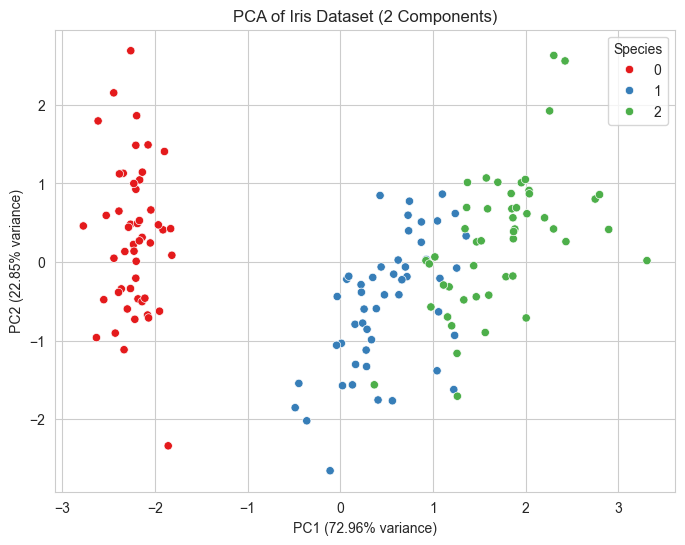

In [13]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_target = iris.target

# Standardize
iris_scaled = StandardScaler().fit_transform(iris_data)

# Apply PCA
pca_iris = PCA(n_components=2)
iris_pc = pca_iris.fit_transform(iris_scaled)

iris_pca_df = pd.DataFrame(iris_pc, columns=['PC1', 'PC2'])
iris_pca_df['target'] = iris_target

print("Explained variance ratio (Iris dataset):")
for i, var in enumerate(pca_iris.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='target', palette='Set1', data=iris_pca_df)
plt.title('PCA of Iris Dataset (2 Components)')
plt.xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.legend(title='Species')
plt.show()